In [54]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import ROOT
plt.style.use("style.mplstyle")


Bad value in file 'style.mplstyle', line 47 ('grid.color: #CCCCCC'): Key grid.color: '' does not look like a color arg
Bad value in file 'style.mplstyle', line 74 ("axes.prop_cycle: cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])"): Key axes.prop_cycle: 'cycler('color', ['' is not a valid cycler construction: unterminated string literal (detected at line 1) (<unknown>, line 1)


In [2]:
dataset = baseClasses.Data()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


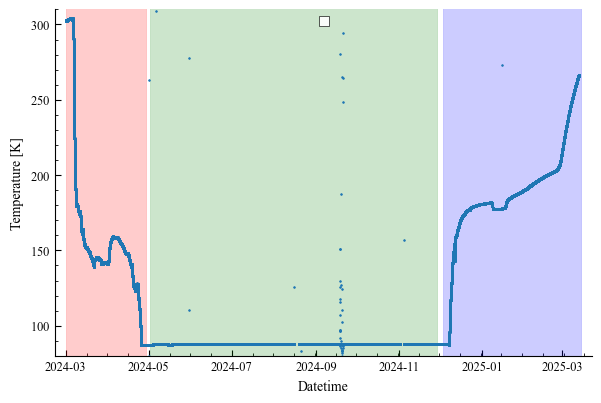

In [24]:
fig, axes = plt.subplots(1,1)
axes.plot(dataset.data.index.values, dataset.data["TE0006"].values, ".", markersize=2.5)
# axes.axvline(datetime.datetime(2024, 4, 30), color="red", label="End of Filling")
axes.fill_betweenx(axes.get_ylim(), datetime.datetime(2024, 3, 1), datetime.datetime(2024, 4, 29), color="red", alpha=0.2)
axes.fill_betweenx(axes.get_ylim(), datetime.datetime(2024, 5, 2), datetime.datetime(2024, 11, 29), color="green", alpha=0.2)
axes.fill_betweenx(axes.get_ylim(), datetime.datetime(2024, 12, 3), datetime.datetime(2025, 3, 15), color="blue", alpha=0.2)
axes.set_ylim(80, 310)
axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.legend(loc="upper center");

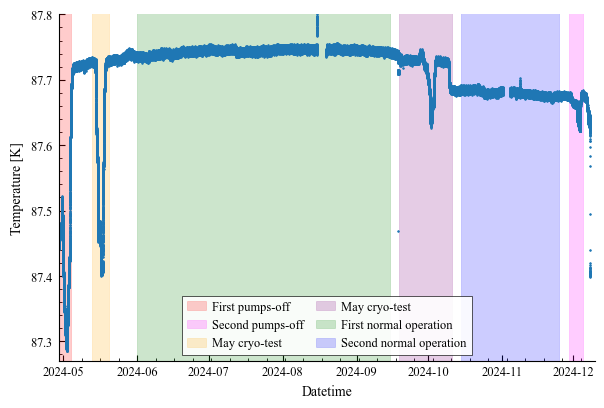

In [57]:
fig, axes = plt.subplots(1,1)
axes.plot(dataset.data.index.values, dataset.data["TE0006"].values, ".", markersize=2.5)
axes.fill_betweenx(axes.get_ylim(), datetime.datetime(2024, 4, 29), datetime.datetime(2024, 5, 4), color="red", alpha=0.2, label="First pumps-off")
axes.fill_betweenx(axes.get_ylim(), datetime.datetime(2024, 11, 29), datetime.datetime(2024, 12, 5), color="magenta", alpha=0.2, label="Second pumps-off")
axes.fill_betweenx(axes.get_ylim(), datetime.datetime(2024, 5, 13), datetime.datetime(2024, 5, 20), color="orange", alpha=0.2, label="May cryo-test")
axes.fill_betweenx(axes.get_ylim(), datetime.datetime(2024, 9, 19), datetime.datetime(2024, 10, 11), color="purple", alpha=0.2, label="May cryo-test")
axes.fill_betweenx(axes.get_ylim(), datetime.datetime(2024, 6, 1), datetime.datetime(2024, 9, 15), color="green", alpha=0.2, label="First normal operation")
axes.fill_betweenx(axes.get_ylim(), datetime.datetime(2024, 10, 15), datetime.datetime(2024, 11, 25), color="blue", alpha=0.2, label="Second normal operation")
axes.set_xlim(datetime.datetime(2024, 4, 29), datetime.datetime(2024, 12, 10))
axes.set_ylim(87.27, 87.8)
axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.legend(loc="lower center", ncol=2);
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/OPERATION/np04_operation.png", dpi=300, format="png")

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 1, 30)) & (dataset.data.index < datetime.datetime(2024, 5, 15))) |
    ((dataset.data.index > datetime.datetime(2024, 12, 1)) & (dataset.data.index < datetime.datetime(2025, 12, 10)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
tgrad.calibrate(calibName="LAR2023_TREE_AVG")
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")

Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  6.90sensor/s]


ERROR: Channel (TE0120) not found


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [02:03<00:00,  2.57s/sensor]
Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG:  23%|██▎       | 11/48 [00:00<00:01, 21.48sensor/s]

ERROR: SensorID (99999) not found in calibration (LAR2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG:  83%|████████▎ | 40/48 [00:02<00:00, 15.24sensor/s]

ERROR: SensorID (40530) not found in calibration (LAR2023_TREE_AVG)
ERROR: SensorID (40529) not found in calibration (LAR2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG: 100%|██████████| 48/48 [00:03<00:00, 13.59sensor/s]
Equalizing PIPE Sensors:  92%|█████████▏| 11/12 [00:34<00:03,  3.03s/sensor]

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:37<00:00,  3.13s/sensor]
Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 12/12 [00:01<00:00, 11.26sensor/s]


In [5]:
cryo = systemClasses.System(dataset=dataset, name="CRYO")
ambient = systemClasses.System(dataset=dataset, name="AMBIENT")
ce = systemClasses.System(dataset=dataset, name="CE")
hv = systemClasses.System(dataset=dataset, name="HV")

Initializing HV Sensors: 100%|██████████| 2/2 [00:00<00:00,  7.56sensor/s]


# Filling

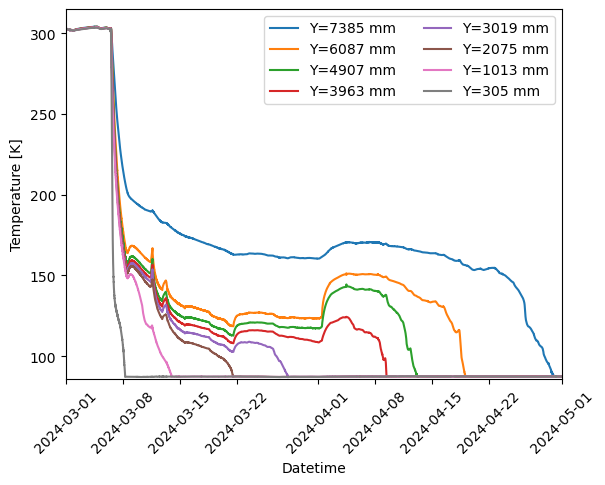

In [6]:
fig, axes = plt.subplots(1,1)
axes.plot(tgrad.sensors[39666].data.index.values, tgrad.sensors[39666].data.values, label=fr"Y={tgrad.sensors[39666].Y:.0f} mm")
axes.plot(tgrad.sensors[39651].data.index.values, tgrad.sensors[39651].data.values, label=fr"Y={tgrad.sensors[39651].Y:.0f} mm")
axes.plot(tgrad.sensors[39649].data.index.values, tgrad.sensors[39649].data.values, label=fr"Y={tgrad.sensors[39649].Y:.0f} mm")
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, label=fr"Y={tgrad.sensors[39644].Y:.0f} mm")
axes.plot(tgrad.sensors[39627].data.index.values, tgrad.sensors[39627].data.values, label=fr"Y={tgrad.sensors[39627].Y:.0f} mm")
axes.plot(tgrad.sensors[39622].data.index.values, tgrad.sensors[39622].data.values, label=fr"Y={tgrad.sensors[39622].Y:.0f} mm")
axes.plot(tgrad.sensors[39613].data.index.values, tgrad.sensors[39613].data.values, label=fr"Y={tgrad.sensors[39613].Y:.0f} mm")
axes.plot(tgrad.sensors[39607].data.index.values, tgrad.sensors[39607].data.values, label=fr"Y={tgrad.sensors[39607].Y:.0f} mm")

axes.set_xlim(datetime.datetime(2024, 3, 1), datetime.datetime(2024, 5, 1))
axes.set_ylim(86,315)
axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.tick_params(axis='x', rotation=45)
axes.legend(loc="upper right", ncol=2)

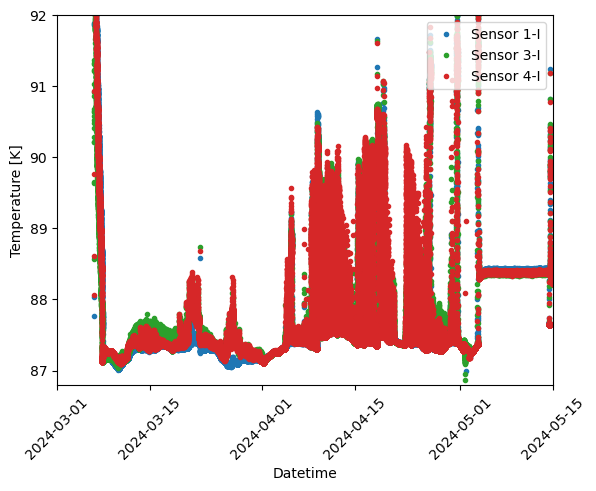

In [7]:
fig, axes = plt.subplots(1,1)
axes.plot(pipe.sensors[49319].data.index.values, pipe.sensors[49319].data.values, ".", color="tab:blue", label=fr"Sensor {pipe.sensors[49319].name}")
# axes.plot(pipe.sensors[49320].data.index.values, pipe.sensors[49320].data.values, label=fr"Y={pipe.sensors[49320].Y:.0f} mm")
axes.plot(pipe.sensors[49321].data.index.values, pipe.sensors[49321].data.values, ".", color="tab:green", label=fr"Sensor {pipe.sensors[49321].name}")
axes.plot(pipe.sensors[49322].data.index.values, pipe.sensors[49322].data.values, ".", color="tab:red", label=fr"Sensor {pipe.sensors[49322].name}")

axes.set_xlim(datetime.datetime(2024, 3, 1), datetime.datetime(2024, 5, 15))
axes.set_ylim(86.8,92)
axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.tick_params(axis='x', rotation=45)
axes.legend(loc="upper right", ncol=1)

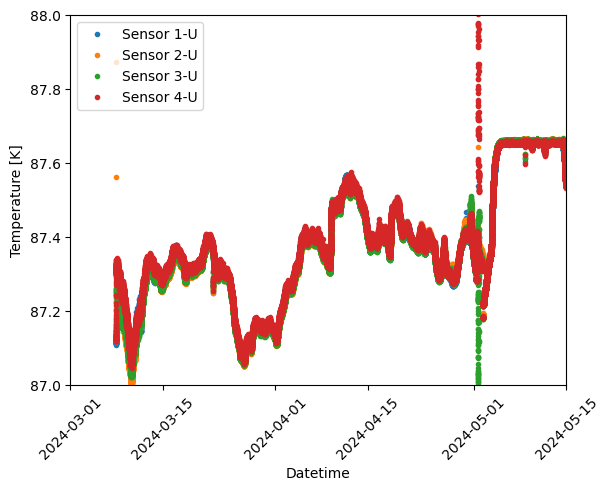

In [8]:
fig, axes = plt.subplots(1,1)
axes.plot(pipe.sensors[39671].data.index.values, pipe.sensors[39671].data.values, ".", color="tab:blue", label=fr"Sensor {pipe.sensors[39671].name}")
axes.plot(pipe.sensors[37131].data.index.values, pipe.sensors[37131].data.values, ".", color="tab:orange", label=fr"Sensor {pipe.sensors[37131].name}")
axes.plot(pipe.sensors[37136].data.index.values, pipe.sensors[37136].data.values, ".", color="tab:green", label=fr"Sensor {pipe.sensors[37136].name}")
axes.plot(pipe.sensors[39669].data.index.values, pipe.sensors[39669].data.values, ".", color="tab:red", label=fr"Sensor {pipe.sensors[39669].name}")

axes.set_xlim(datetime.datetime(2024, 3, 1), datetime.datetime(2024, 5, 15))
axes.set_ylim(87,88)
axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.tick_params(axis='x', rotation=45)
axes.legend(loc="upper left", ncol=1)

Text(0, 0.5, 'Pump Differential Pressure [mbar]')

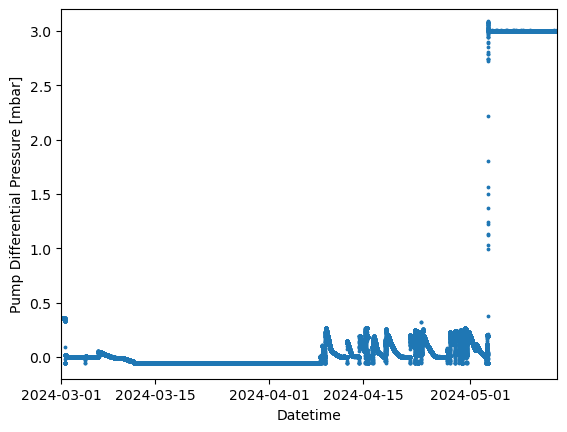

In [39]:
fig, axes = plt.subplots(1,1)
axes.plot(cryo.sensors[1048].data.index.values, cryo.sensors[1048].data.values, ".", markersize=3.5, color="tab:blue", )
axes.set_xlim(datetime.datetime(2024, 3, 1), datetime.datetime(2024, 5, 14))
axes.set_ylim(-0.2,3.2)
axes.set_xlabel("Datetime")
axes.set_ylabel("Pump Differential Pressure [mbar]")
# axes.tick_params(axis='x', rotation=45)
# axes.legend(loc="upper left", ncol=1)

Text(0, 0.5, 'Pressure [bar]')

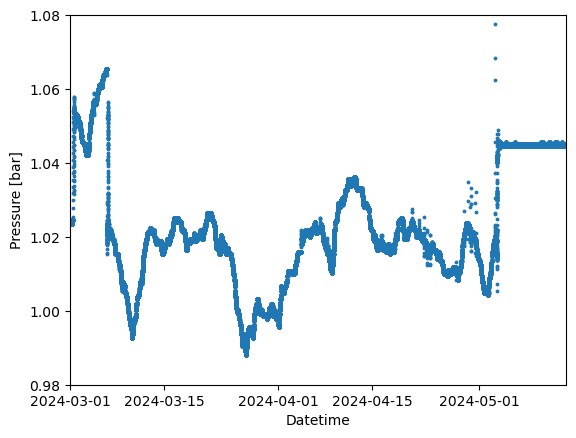

In [49]:
fig, axes = plt.subplots(1,1)
axes.plot(cryo.sensors[1011].data.index.values, cryo.sensors[1011].data.values, ".", markersize=3.5, color="tab:blue")
axes.set_xlim(datetime.datetime(2024, 3, 1), datetime.datetime(2024, 5, 14))
axes.set_ylim(0.98,1.08)
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure [bar]")
# axes.tick_params(axis='x', rotation=45)
# axes.legend(loc="upper left", ncol=1)

# Emptying

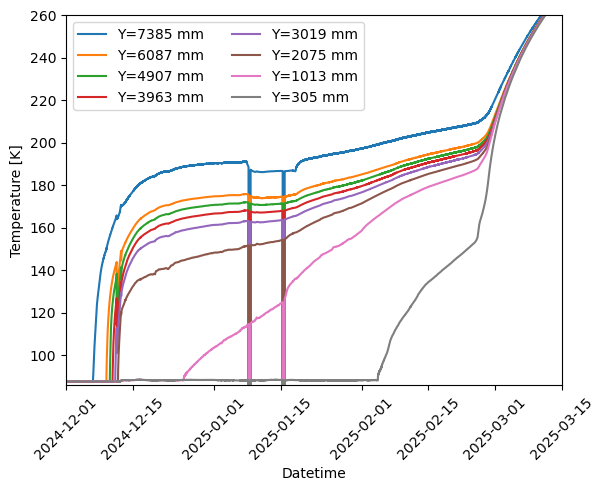

In [7]:
fig, axes = plt.subplots(1,1)
axes.plot(tgrad.sensors[39666].data.index.values, tgrad.sensors[39666].data.values, label=fr"Y={tgrad.sensors[39666].Y:.0f} mm")
axes.plot(tgrad.sensors[39651].data.index.values, tgrad.sensors[39651].data.values, label=fr"Y={tgrad.sensors[39651].Y:.0f} mm")
axes.plot(tgrad.sensors[39649].data.index.values, tgrad.sensors[39649].data.values, label=fr"Y={tgrad.sensors[39649].Y:.0f} mm")
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, label=fr"Y={tgrad.sensors[39644].Y:.0f} mm")
axes.plot(tgrad.sensors[39627].data.index.values, tgrad.sensors[39627].data.values, label=fr"Y={tgrad.sensors[39627].Y:.0f} mm")
axes.plot(tgrad.sensors[39622].data.index.values, tgrad.sensors[39622].data.values, label=fr"Y={tgrad.sensors[39622].Y:.0f} mm")
axes.plot(tgrad.sensors[39613].data.index.values, tgrad.sensors[39613].data.values, label=fr"Y={tgrad.sensors[39613].Y:.0f} mm")
axes.plot(tgrad.sensors[39607].data.index.values, tgrad.sensors[39607].data.values, label=fr"Y={tgrad.sensors[39607].Y:.0f} mm")

axes.set_xlim(datetime.datetime(2024, 12, 1), datetime.datetime(2025, 3, 15))
axes.set_ylim(86,260)
axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.tick_params(axis='x', rotation=45)
axes.legend(loc="upper left", ncol=2)

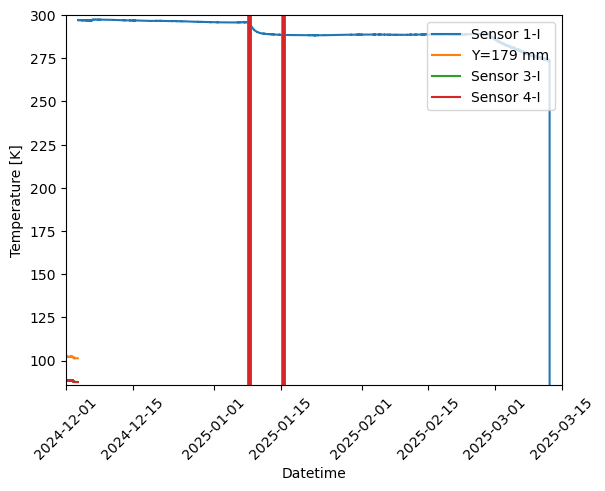

In [23]:
fig, axes = plt.subplots(1,1)
axes.plot(pipe.sensors[49319].data.index.values, pipe.sensors[49319].data.values, label=fr"Sensor {pipe.sensors[49319].name}")
axes.plot(pipe.sensors[49320].data.index.values, pipe.sensors[49320].data.values, label=fr"Y={pipe.sensors[49320].Y:.0f} mm")
axes.plot(pipe.sensors[49321].data.index.values, pipe.sensors[49321].data.values, label=fr"Sensor {pipe.sensors[49321].name}")
axes.plot(pipe.sensors[49322].data.index.values, pipe.sensors[49322].data.values, label=fr"Sensor {pipe.sensors[49322].name}")

axes.set_xlim(datetime.datetime(2024, 12, 1), datetime.datetime(2025, 3, 15))
axes.set_ylim(86,300)
axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.tick_params(axis='x', rotation=45)
axes.legend(loc="upper right", ncol=1)